In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('supermarket_sales - Sheet1.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
total=df['Unit price']*df['Quantity']+df['Tax 5%']
total

0       548.9715
1        80.2200
2       340.5255
3       489.0480
4       634.3785
         ...    
995      42.3675
996    1022.4900
997      33.4320
998      69.1110
999     649.2990
Length: 1000, dtype: float64

In [4]:
gross_income=(df['Total']-df['cogs'])/df['Total']*100
gross_income

0      4.761905
1      4.761905
2      4.761905
3      4.761905
4      4.761905
         ...   
995    4.761905
996    4.761905
997    4.761905
998    4.761905
999    4.761905
Length: 1000, dtype: float64

In [7]:
for i in df:
    if df[i].dtype=='O':
        print(i,'....',df[i].dtype)

Invoice ID .... object
Branch .... object
City .... object
Customer type .... object
Gender .... object
Product line .... object
Date .... object
Time .... object
Payment .... object


In [9]:
numeric=[i for i in df if df[i].dtype!='O']
print(numeric)

['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [23]:
for i in df:
    if df[i].dtype=='O':
        if i!='Invoice ID' and i!='Date' and i!='Time':
            print('columns',i)
            print('no of unique values in',i,df[i].nunique())
            print('name of unique values in',i,df[i].unique())
            print('value of count of',df[i].value_counts())
            print()

columns Branch
no of unique values in Branch 3
name of unique values in Branch ['A' 'C' 'B']
value of count of Branch
A    340
B    332
C    328
Name: count, dtype: int64

columns City
no of unique values in City 3
name of unique values in City ['Yangon' 'Naypyitaw' 'Mandalay']
value of count of City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

columns Customer type
no of unique values in Customer type 2
name of unique values in Customer type ['Member' 'Normal']
value of count of Customer type
Member    501
Normal    499
Name: count, dtype: int64

columns Gender
no of unique values in Gender 2
name of unique values in Gender ['Female' 'Male']
value of count of Gender
Female    501
Male      499
Name: count, dtype: int64

columns Product line
no of unique values in Product line 6
name of unique values in Product line ['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']
value o

In [25]:
z= df.select_dtypes(include='O')
z.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Date,Time,Payment
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,1/5/2019,13:08,Ewallet
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,3/8/2019,10:29,Cash
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,3/3/2019,13:23,Credit card
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,1/27/2019,20:33,Ewallet
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,2/8/2019,10:37,Ewallet


In [28]:
l=['violet','indigo','orange','lime','red','pink']
plt.figure(figsize=(22,20),dpi=500)
c=1
for i in z:
    if i!='Invoice ID' and i!= 'Date' and i!='Time':
        plt.subplot(2,3,c)
        sns.countplot(x=z[i],data=z,palette=l)
        if i!='Product line':
            plt.xticks(fontsize=20)
            plt.xlabel(i,fontsize=30)
            c+=1
        else:
            plt.xticks(rotation=90,fontsize=20)
            plt.xlabel(i,fontsize=30)
            c+=1
plt.show()
    

In [31]:
k=df.groupby(['Product line','Branch'])['gross income'].agg(['count','mean']).reset_index()
k

,Product line,Branch,count,mean
0,Electronic accessories,A,60,14.537392
1,Electronic accessories,B,55,14.763155
2,Electronic accessories,C,55,16.423355
3,Fashion accessories,A,51,15.249775
4,Fashion accessories,B,62,12.606234
5,Fashion accessories,C,65,15.794923
6,Food and beverages,A,58,14.091216
7,Food and beverages,B,50,14.490370
8,Food and beverages,C,66,17.147803
9,Health and beauty,A,47,12.763681


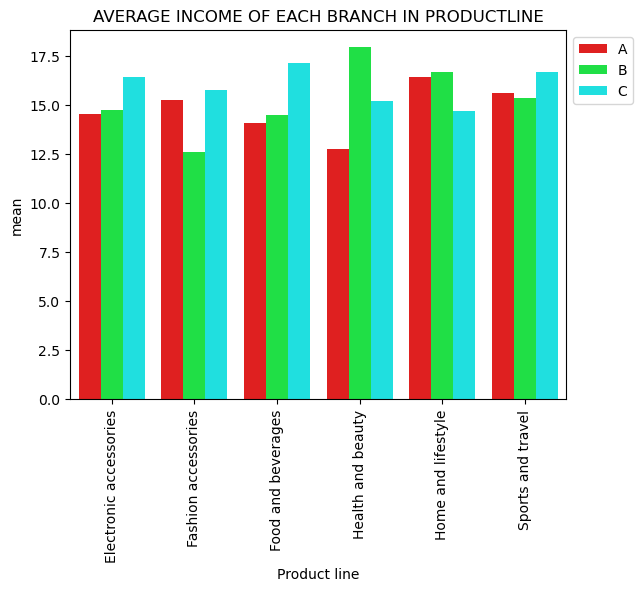

In [41]:
s=['#FF0000','#00FF33','#00FFFF']
plt.title('AVERAGE INCOME OF EACH BRANCH IN PRODUCTLINE')
sns.barplot(x='Product line',y='mean',hue='Branch',data=k,palette=s)
plt.legend(bbox_to_anchor=(1,1))
plt.xticks(rotation=90)
plt.show()

# WHICH IS THE BEST SELLING BRANCH?

In [44]:
g=df.groupby('Branch')['gross income'].sum().reset_index()
g

,Branch,gross income
0,A,5057.1605
1,B,5057.0320
2,C,5265.1765


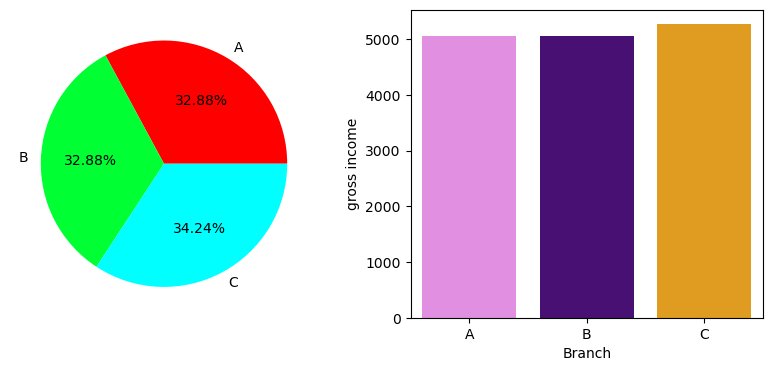

In [52]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.pie('gross income',labels='Branch',data=g,autopct='%0.2f%%',colors=s)
plt.subplot(1,2,2)
sns.barplot(x='Branch',y='gross income',data=g,palette=l);

# WHICH BRANCH HAS HIGHEST RATING?

In [55]:
r=df.groupby('Branch')['Rating'].mean().reset_index()
r

,Branch,Rating
0,A,7.027059
1,B,6.818072
2,C,7.072866


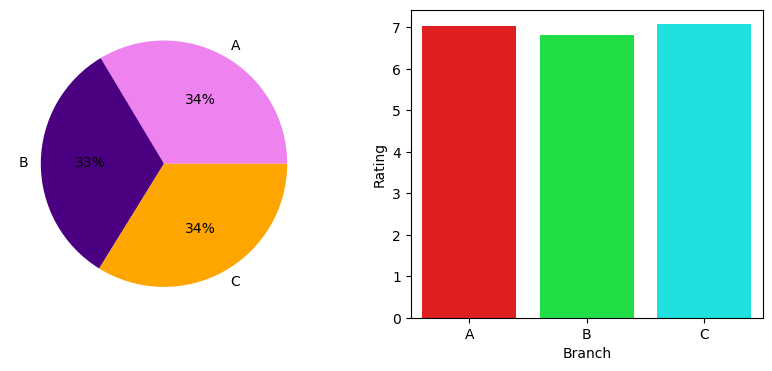

In [56]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.pie('Rating',labels='Branch',data=r,autopct='%0.0f%%',colors=l)
plt.subplot(1,2,2)
sns.barplot(x='Branch',y='Rating',data=r,palette=s);

In [59]:
c=df[df['Branch']=='C']
c

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,18:30,Ewallet,597.73,4.761905,29.8865,4.1
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0
20,300-71-4605,C,Naypyitaw,Member,Male,Electronic accessories,86.04,5,21.5100,451.7100,2/25/2019,11:24,Ewallet,430.20,4.761905,21.5100,4.8
34,183-56-6882,C,Naypyitaw,Member,Female,Food and beverages,99.42,4,19.8840,417.5640,2/6/2019,10:42,Ewallet,397.68,4.761905,19.8840,7.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983,148-41-7930,C,Naypyitaw,Normal,Male,Health and beauty,99.96,7,34.9860,734.7060,1/23/2019,10:33,Cash,699.72,4.761905,34.9860,6.1
984,189-40-5216,C,Naypyitaw,Normal,Male,Electronic accessories,96.37,7,33.7295,708.3195,1/9/2019,11:40,Cash,674.59,4.761905,33.7295,6.0
988,267-62-7380,C,Naypyitaw,Member,Male,Electronic accessories,82.34,10,41.1700,864.5700,3/29/2019,19:12,Ewallet,823.40,4.761905,41.1700,4.3
994,652-49-6720,C,Naypyitaw,Member,Female,Electronic accessories,60.95,1,3.0475,63.9975,2/18/2019,11:40,Ewallet,60.95,4.761905,3.0475,5.9


In [57]:
c=df.groupby('Customer type')['gross income'].sum().reset_index()
c

,Customer type,gross income
0,Member,7820.164
1,Normal,7559.205


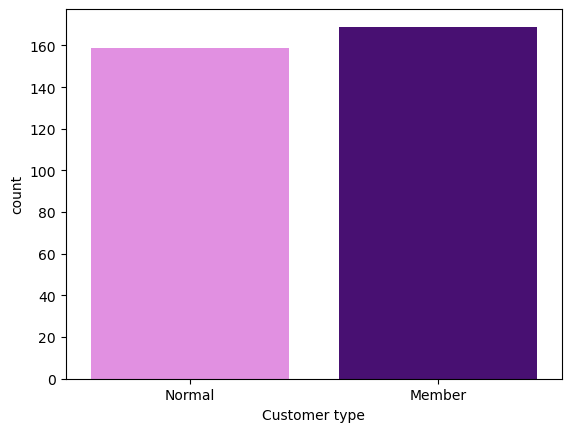

In [61]:
sns.countplot(x='Customer type',data=c,palette=l);

# WHICH DAY HAS MOST GROSS INCOME?

In [63]:
df['Date']=pd.to_datetime(df['Date'])
df['Days']=df['Date'].dt.day_name()
df['month']=df['Date'].dt.month_name()

In [68]:
df['weeks']=df['Days'].apply(lambda x : 'WEEKDAY'if x=='Monday' or x=='Tuesday' or x=='Wednesday' or x=='Thursday' or x=='Friday' else 'WEEKEND' )

In [69]:
df.groupby('weeks')['gross income'].sum().reset_index()

,weeks,gross income
0,WEEKDAY,10589.907
1,WEEKEND,4789.462


In [72]:
d=df.groupby(['month','Days'])['gross income'].sum().reset_index().sort_values(by='gross income',ascending=False)
d

,month,Days,gross income
16,March,Saturday,1227.1870
12,January,Tuesday,1009.7385
11,January,Thursday,924.5895
9,January,Saturday,861.6040
13,January,Wednesday,848.0180
19,March,Tuesday,838.6350
0,February,Friday,800.1090
3,February,Sunday,791.9515
14,March,Friday,757.3600
10,January,Sunday,683.6550


In [74]:
df.groupby(['month'])['gross income'].sum().reset_index().sort_values(by='gross income',ascending=False)


,month,gross income
1,January,5537.708
2,March,5212.167
0,February,4629.494


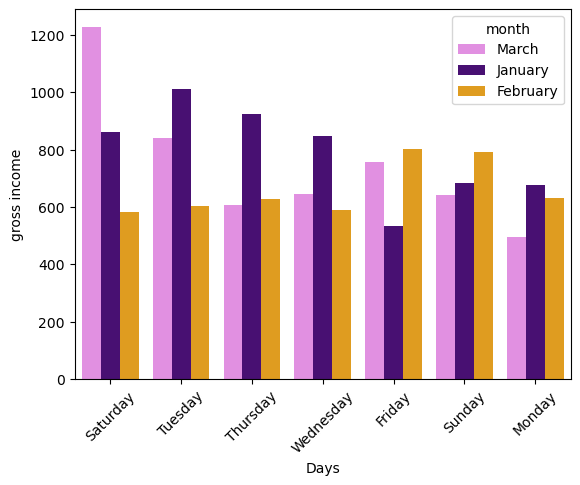

In [77]:
sns.barplot(x='Days',y='gross income',hue='month',data=d,palette=l)
plt.xticks(rotation=45);

# WHICH MODE OF PAYMENT IS HIGH?

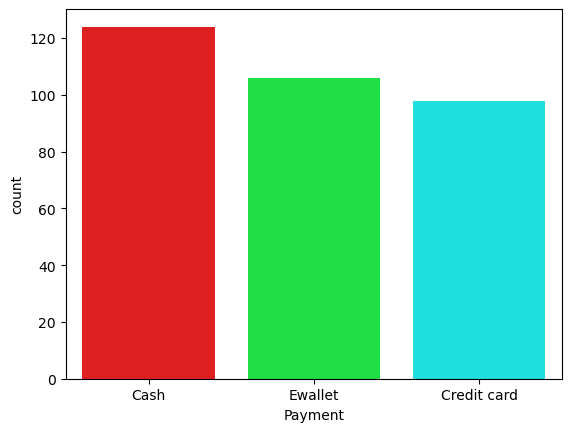

In [80]:
sns.countplot(x='Payment',data=c,palette=s);

In [81]:
df.groupby(['Gender','Customer type','Payment'])['gross income'].agg(['sum','count'])

sum  count
Gender Customer type Payment                      
Female Member        Cash         1424.4920     90
                     Credit card  1476.3550     90
                     Ewallet      1296.6265     81
       Normal        Cash         1409.5180     88
                     Credit card  1071.1900     73
                     Ewallet      1316.2435     79
Male   Member        Cash         1178.4135     78
                     Credit card  1274.6675     82
                     Ewallet      1169.6095     80
       Normal        Cash         1330.7465     88
                     Credit card   976.2195     66
                     Ewallet      1455.2875    105

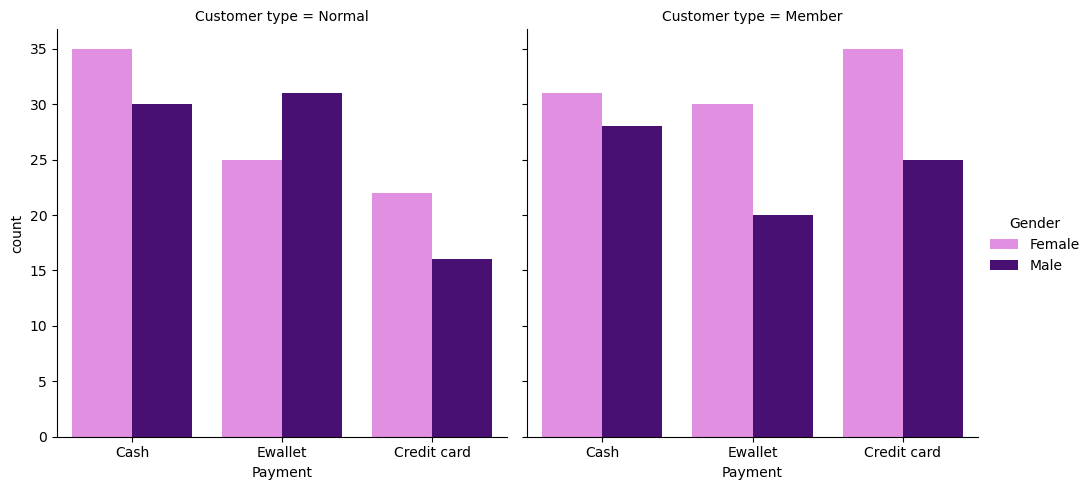

In [85]:
sns.catplot(x='Payment',hue='Gender',col='Customer type',kind='count',data=c,palette=l);

# calculate the gross income with respect to product line

In [87]:
Products=c.groupby(['Product line'])['gross income'].sum().reset_index()
Products

,Product line,gross income
0,Electronic accessories,903.2845
1,Fashion accessories,1026.6700
2,Food and beverages,1131.7550
3,Health and beauty,791.2060
4,Home and lifestyle,661.6930
5,Sports and travel,750.5680


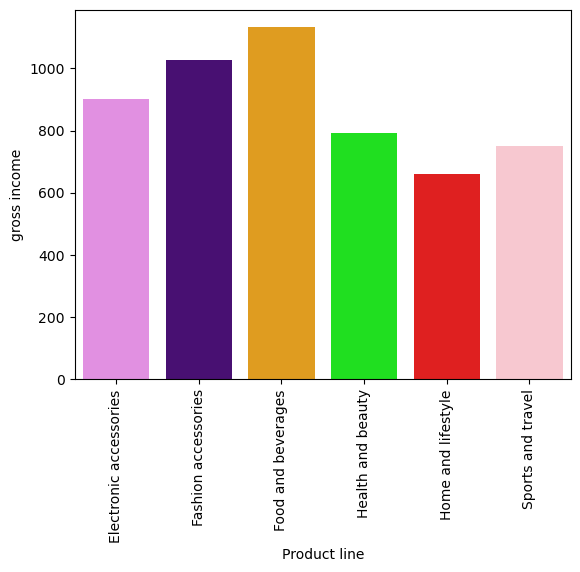

In [90]:
sns.barplot(x='Product line',y='gross income',data=Products,palette=l);
plt.xticks(rotation=90);

In [92]:
df['Time']=pd.to_datetime(df['Time'])
df['Hour']=df['Time'].dt.hour

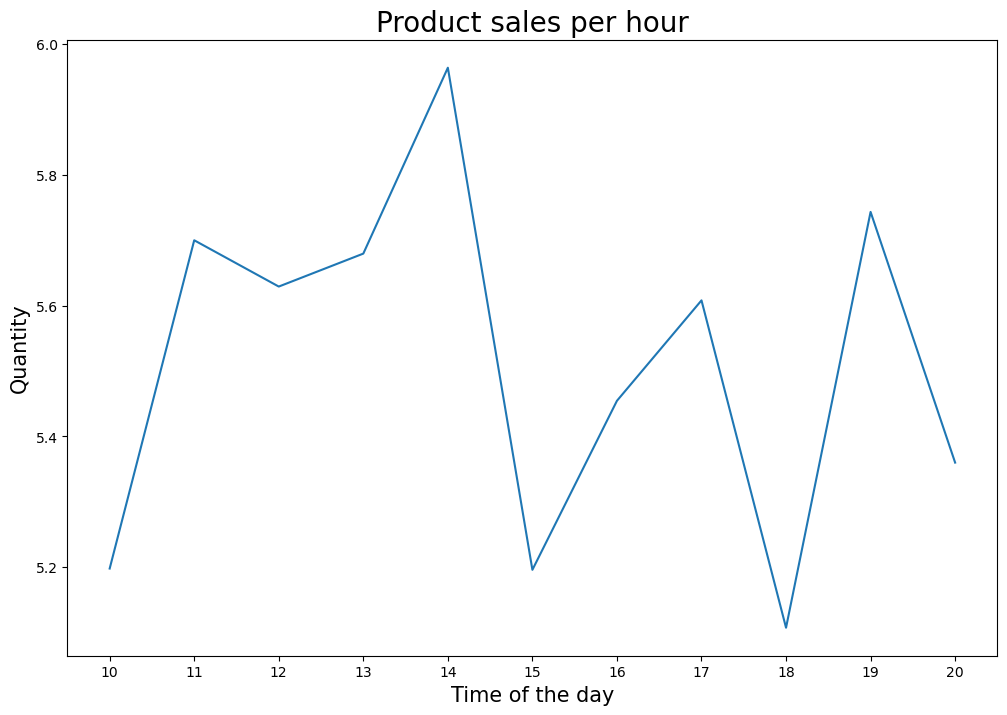

In [94]:
plt.figure(figsize=(12,8))
sns.lineplot(x='Hour',y='Quantity',data=df,ci=None)
plt.title('Product sales per hour', fontsize=20)
plt.xlabel('Time of the day', fontsize=15)
plt.xticks(df['Hour'].unique())
# plt.yticks(df['Quantity'].unique())
plt.ylabel('Quantity', fontsize=15);

#  INSIGHTS: We can see that the sales is highest at 2pm. Good volume of sales is recorded around 5pm and 7pm. The sales is recorded to be the lowest around 10pm, 3pm and 4pm.

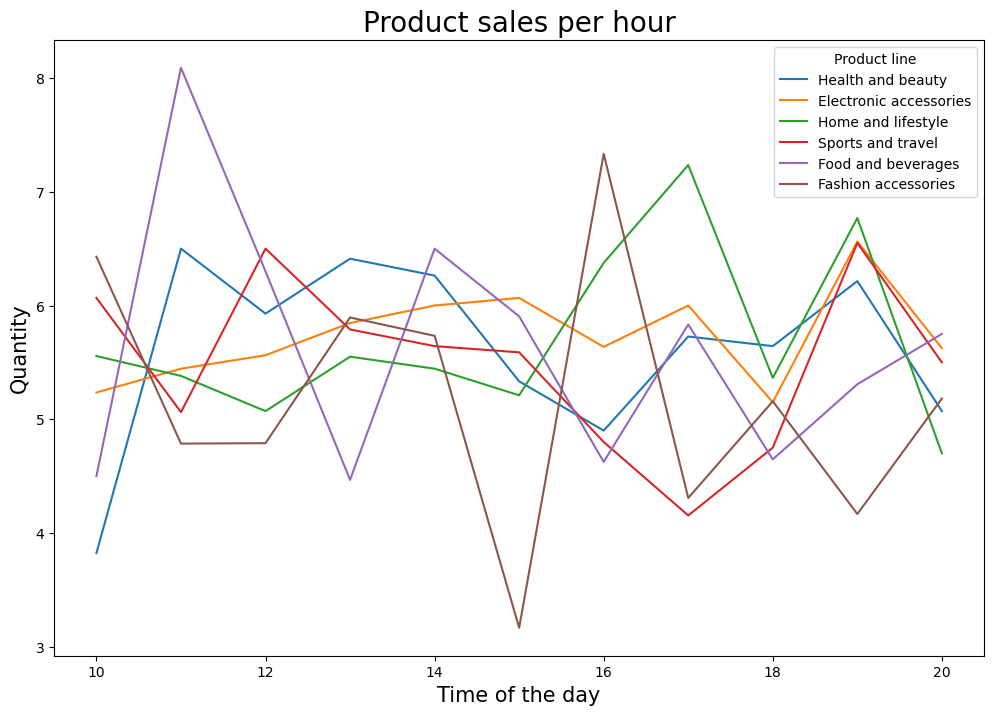

In [96]:
plt.figure(figsize=(12,8))
sns.lineplot(x='Hour',y='Quantity',data=df, hue='Product line',ci=None)
plt.title('Product sales per hour', fontsize=20)
plt.xlabel('Time of the day', fontsize=15)
plt.ylabel('Quantity', fontsize=15);

#  Health and Beauty products has no specific time of purchase Electronic sales are seen around 7 pm which is the end of daily work, when family can enjoy such shopping. Home and lifestyle is recorded around 5 pm and 7 pm which can be an ideal time for homemakers to make such purchases. Food and beverages are seen to be purchased more at 11 am which is an ideal time to purchase daily or weekly food items. Fashion accessories are seen to be purchased at 4 pm which can be an ideal time not only for adults but also for teenagers.